# **Strava Fitness Data Analysis**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

The data set has 18 files where 3 files are in both wide and long format

dailyActivity_merged file = dailyCalories_merged + dailySteps_merged + dailyIntensities_merged

In Remaining files the data is in minutes,hours and seconds, if you want to go into minute analysis you can use all those files. 

In this Analysis , we are taking only the dailyActivity data (calories,steps,activity details), sleepday , weightlog data and heart_rate data

In [2]:
dailyActivity = pd.read_csv("C:\\Users\\HI\\Labmentix_Projects\\Strava\\Data files\\dailyActivity_merged.csv")
Wlog_info = pd.read_csv("C:\\Users\\HI\\Labmentix_Projects\\Strava\\Data files\\weightLogInfo_merged.csv")
Sleep_info = pd.read_csv("C:\\Users\\HI\\Labmentix_Projects\\Strava\\Data files\\sleepDay_merged.csv")
Hrate_sec = pd.read_csv("C:\\Users\\HI\\Labmentix_Projects\\Strava\\Data files\\heartrate_seconds_merged.csv")

### 1 Process




#### **1.1 Removing duplicates**


We are removing duplicate rows by using Id, Date as primary key

In [3]:
print(dailyActivity.duplicated().sum())
print(Wlog_info.duplicated().sum())
print(Sleep_info.duplicated().sum())
print(Hrate_sec.duplicated().sum())

0
0
3
0


In [4]:
Sleep_info = Sleep_info.drop_duplicates()

#### **1.2 Viewing the datasets**

In [5]:
dailyActivity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [6]:
Sleep_info.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [7]:
Hrate_sec.head()

,Id,Time,Value
0,2022484408,4/12/2016 7:21:00 AM,97
1,2022484408,4/12/2016 7:21:05 AM,102
2,2022484408,4/12/2016 7:21:10 AM,105
3,2022484408,4/12/2016 7:21:20 AM,103
4,2022484408,4/12/2016 7:21:25 AM,101


#### **1.3 changing date to consistent format**

Date is present in m/d/y format changing to d/m/y format in all the four files

In [8]:
dailyActivity['ActivityDate'] = pd.to_datetime(dailyActivity['ActivityDate'])
Hrate_sec['Time'] = pd.to_datetime(Hrate_sec['Time'])
Sleep_info['SleepDay'] = pd.to_datetime(Sleep_info['SleepDay'])
Wlog_info['Date'] = pd.to_datetime(Wlog_info['Date'])

#### **1.4 Adding new Columns**

We are adding column months which contains name of months

In [9]:
dailyActivity['Month'] = dailyActivity['ActivityDate'].dt.month_name()
Hrate_sec['Month'] = Hrate_sec['Time'].dt.month_name()
Sleep_info['Month'] = Sleep_info['SleepDay'].dt.month_name()
Wlog_info['Month'] = Wlog_info['Date'].dt.month_name()

we are adding column Weekday which contains week name

In [10]:
dailyActivity['Weekday'] = dailyActivity['ActivityDate'].dt.day_name()
Hrate_sec['Weekday'] = Hrate_sec['Time'].dt.day_name()
Sleep_info['Weekday'] = Sleep_info['SleepDay'].dt.day_name()
Wlog_info['Weekday'] = Wlog_info['Date'].dt.day_name()

#### **1.5 Statistical summary of the variables**

checking the data type and the statistical summary of each variable

In [11]:
dailyActivity.describe()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,9.400000e+02,940,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.855407e+09,2016-04-26 06:53:37.021276672,7637.910638,5.489702,5.475351,0.108171,1.502681,0.567543,3.340819,0.001606,21.164894,13.564894,192.812766,991.210638,2303.609574
min,1.503960e+09,2016-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,2016-04-19 00:00:00,3789.750000,2.620000,2.620000,0.000000,0.000000,0.000000,1.945000,0.000000,0.000000,0.000000,127.000000,729.750000,1828.500000
50%,4.445115e+09,2016-04-26 00:00:00,7405.500000,5.245000,5.245000,0.000000,0.210000,0.240000,3.365000,0.000000,4.000000,6.000000,199.000000,1057.500000,2134.000000
75%,6.962181e+09,2016-05-04 00:00:00,10727.000000,7.712500,7.710000,0.000000,2.052500,0.800000,4.782500,0.000000,32.000000,19.000000,264.000000,1229.500000,2793.250000
max,8.877689e+09,2016-05-12 00:00:00,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,143.000000,518.000000,1440.000000,4900.000000
std,2.424805e+09,NaN,5087.150742,3.924606,3.907276,0.619897,2.658941,0.883580,2.040655,0.007346,32.844803,19.987404,109.174700,301.267437,718.166862


In [12]:
dailyActivity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[ns]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinutes       940 non-null    int64         
 12  LightlyActiveMinutes  

In [13]:
Hrate_sec.describe()

,Id,Time,Value
count,2.483658e+06,2483658,2.483658e+06
mean,5.513765e+09,2016-04-26 19:43:52.237666304,7.732842e+01
min,2.022484e+09,2016-04-12 00:00:00,3.600000e+01
25%,4.388162e+09,2016-04-19 06:18:10,6.300000e+01
50%,5.553957e+09,2016-04-26 20:28:50,7.300000e+01
75%,6.962181e+09,2016-05-04 08:00:20,8.800000e+01
max,8.877689e+09,2016-05-12 16:20:00,2.030000e+02
std,1.950224e+09,NaN,1.940450e+01


In [14]:
Hrate_sec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2483658 entries, 0 to 2483657
Data columns (total 5 columns):
 #   Column   Dtype         
---  ------   -----         
 0   Id       int64         
 1   Time     datetime64[ns]
 2   Value    int64         
 3   Month    object        
 4   Weekday  object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 94.7+ MB


In [15]:
Sleep_info.describe()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
count,4.100000e+02,410,410.000000,410.000000,410.000000
mean,4.994963e+09,2016-04-26 11:38:55.609756160,1.119512,419.173171,458.482927
min,1.503960e+09,2016-04-12 00:00:00,1.000000,58.000000,61.000000
25%,3.977334e+09,2016-04-19 00:00:00,1.000000,361.000000,403.750000
50%,4.702922e+09,2016-04-27 00:00:00,1.000000,432.500000,463.000000
75%,6.962181e+09,2016-05-04 00:00:00,1.000000,490.000000,526.000000
max,8.792010e+09,2016-05-12 00:00:00,3.000000,796.000000,961.000000
std,2.060863e+09,NaN,0.346636,118.635918,127.455140


In [16]:
Sleep_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 410 entries, 0 to 412
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Id                  410 non-null    int64         
 1   SleepDay            410 non-null    datetime64[ns]
 2   TotalSleepRecords   410 non-null    int64         
 3   TotalMinutesAsleep  410 non-null    int64         
 4   TotalTimeInBed      410 non-null    int64         
 5   Month               410 non-null    object        
 6   Weekday             410 non-null    object        
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 25.6+ KB


In [17]:
Wlog_info.describe()

,Id,Date,WeightKg,WeightPounds,Fat,BMI,LogId
count,6.700000e+01,67,67.000000,67.000000,2.00000,67.000000,6.700000e+01
mean,7.009282e+09,2016-04-27 15:39:54.283582208,72.035821,158.811801,23.50000,25.185224,1.461772e+12
min,1.503960e+09,2016-04-12 06:47:11,52.599998,115.963147,22.00000,21.450001,1.460444e+12
25%,6.962181e+09,2016-04-19 15:19:45,61.400002,135.363832,22.75000,23.959999,1.461079e+12
50%,6.962181e+09,2016-04-27 23:59:59,62.500000,137.788914,23.50000,24.389999,1.461802e+12
75%,8.877689e+09,2016-05-04 15:24:10.500000,85.049999,187.503152,24.25000,25.559999,1.462375e+12
max,8.877689e+09,2016-05-12 23:59:59,133.500000,294.317120,25.00000,47.540001,1.463098e+12
std,1.950322e+09,NaN,13.923206,30.695415,2.12132,3.066963,7.829948e+08


In [18]:
Wlog_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Id              67 non-null     int64         
 1   Date            67 non-null     datetime64[ns]
 2   WeightKg        67 non-null     float64       
 3   WeightPounds    67 non-null     float64       
 4   Fat             2 non-null      float64       
 5   BMI             67 non-null     float64       
 6   IsManualReport  67 non-null     bool          
 7   LogId           67 non-null     int64         
 8   Month           67 non-null     object        
 9   Weekday         67 non-null     object        
dtypes: bool(1), datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 4.9+ KB


### **2. Analysing Datasets** 

In [19]:
print(dailyActivity['Id'].nunique())
print(Wlog_info['Id'].nunique())
print(Sleep_info['Id'].nunique())
print(Hrate_sec['Id'].nunique())

33
8
24
14


In [20]:
print(dailyActivity.shape)
print(Wlog_info.shape)
print(Sleep_info.shape)
print(Hrate_sec.shape)

(940, 17)
(67, 10)
(410, 7)
(2483658, 5)


We are not merging the three files because in the 

* **daily_Activity** there are 33 respondents with 940 rows
* **daily_sleep** we have 24 respondents with 413 rows
* **weight_info** we have 8 respondents with 67 rows
* **Heart_ratesec** there are 14 respondents with 2483658 rows

So if we merge all the 3 files with common data we will loose lot of data. so trying to analyse them individually

In [21]:
dailyActivity.groupby('Month')['ActivityDate'].nunique()

Month
April    19
May      12
Name: ActivityDate, dtype: int64

In [22]:
dailyActivity.groupby('Month')['Id'].nunique()

Month
April    33
May      30
Name: Id, dtype: int64

In [23]:
april_ids = set(dailyActivity[dailyActivity['ActivityDate'].dt.to_period('M') == '2016-04']['Id'])
may_ids = set(dailyActivity[dailyActivity['ActivityDate'].dt.to_period('M') == '2016-05']['Id'])

april_ids - may_ids

{2347167796, 4057192912, 8253242879}

In [24]:
print(dailyActivity[dailyActivity['Id'] == 2347167796]['ActivityDate'].dt.date.nunique())
print(dailyActivity[dailyActivity['Id'] == 4057192912]['ActivityDate'].dt.date.nunique())
print(dailyActivity[dailyActivity['Id'] == 8253242879]['ActivityDate'].dt.date.nunique())

18
4
19


Dataset generated by the Strava_APP is between 12.04.2016-12.05.2016 i.e., (31 days)


* April - 19 days  - 33 respondents
* May - 12 days - 30 respondents

Totally there are 33 respondents

3 repondents who are in April are not there in May

* 2347167796 -- Active for 18 days
* 4057192912 -- Active for 4 days
* 8253242879 -- Active for 19 days


For Analysis I have used Average, as the sum will be misleading as the no. of respondents changed each month and  the no. of days data we have vary per month



#### **2.1 Average calories burnt per month**



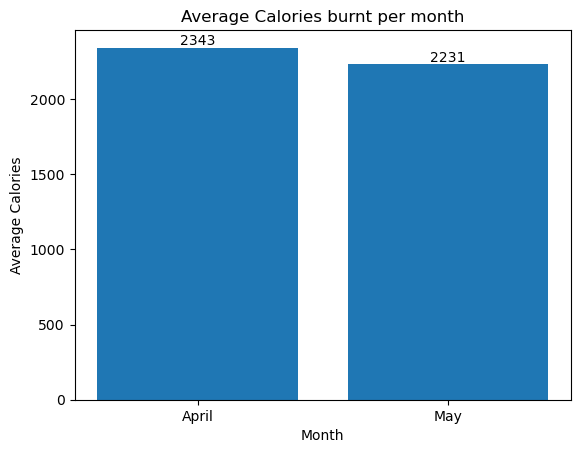

In [25]:
# Calculate the average value of 'calories' for each 'Month'
avg_values = dailyActivity.groupby('Month')['Calories'].mean().reset_index()

# Create the bar chart
fig, ax = plt.subplots()
bars = ax.bar(avg_values['Month'], avg_values['Calories'])

# Add the average values on top of the bars using ax.bar_label()
ax.bar_label(bars, fmt='%.0f') # fmt='%.2f' formats the label to two decimal places

# Customize the chart
plt.title('Average Calories burnt per month')
plt.xlabel('Month')
plt.ylabel('Average Calories')
plt.show()


#### **2.2 Average Steps per month**

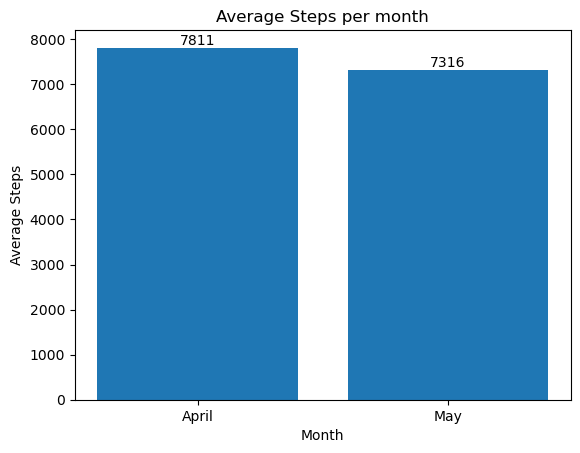

In [26]:
# Calculate the average value of 'calories' for each 'Month'
avg_values = dailyActivity.groupby('Month')['TotalSteps'].mean().reset_index()

# Create the bar chart
fig, ax = plt.subplots()
bars = ax.bar(avg_values['Month'], avg_values['TotalSteps'])

# Add the average values on top of the bars using ax.bar_label()
ax.bar_label(bars, fmt='%.0f') # fmt='%.2f' formats the label to two decimal places

# Customize the chart
plt.title('Average Steps per month')
plt.xlabel('Month')
plt.ylabel('Average Steps')
plt.show()


#### **2.3 Average Steps taken by each participant per week**

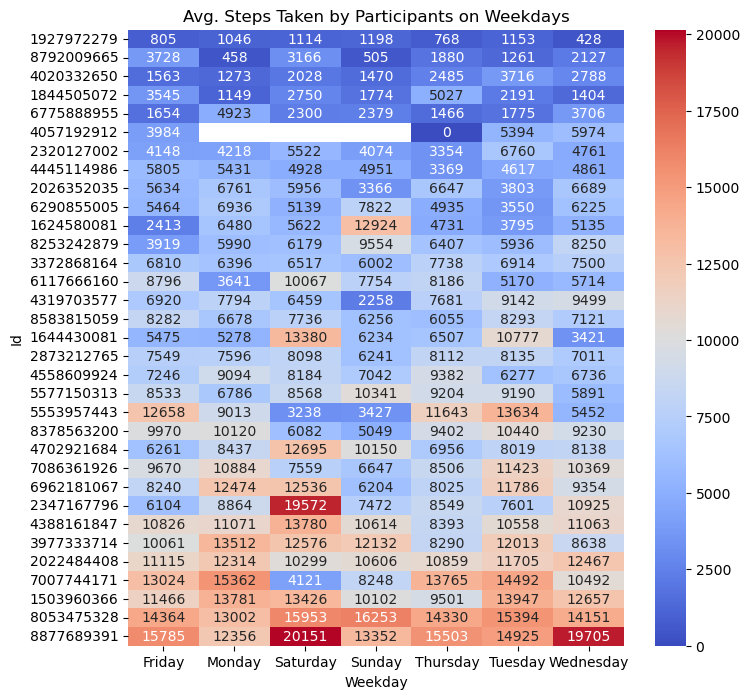

In [27]:
pivot = dailyActivity.pivot_table(values='TotalSteps',index='Id',columns='Weekday',aggfunc='mean')
pivot["Avg_TotalSteps"] = pivot.mean(axis=1)
pivot = pivot.sort_values("Avg_TotalSteps", ascending=True)
pivot = pivot.drop(columns=["Avg_TotalSteps"])

plt.figure(figsize=(8,8))
sns.heatmap(pivot,cmap="coolwarm",annot=True,fmt=".0f")
plt.title("Avg. Steps Taken by Participants on Weekdays")
plt.show()

#### **2.3.1 Average Steps taken per week**

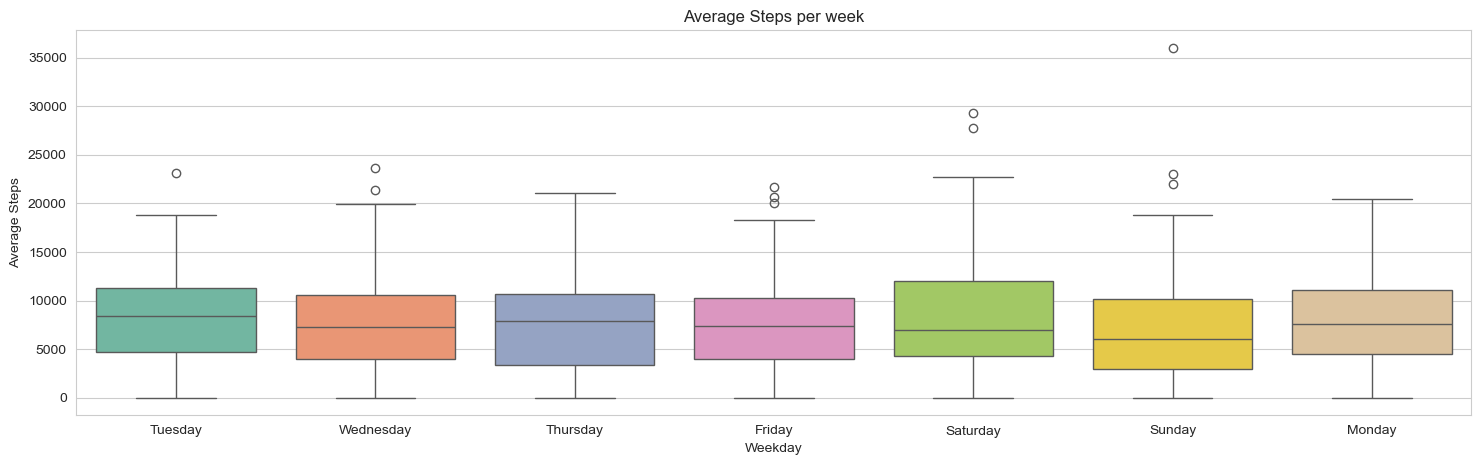

In [29]:
# Calculate the average value of 'steps' for each 'week'

plt.figure(figsize = (18,5))
sns.set_style('whitegrid')

sns.boxplot(data=dailyActivity, x='Weekday', y='TotalSteps', palette='Set2')

plt.title('Average Steps per week')
plt.xlabel('Weekday')
plt.ylabel('Average Steps')
plt.show()


* Approximately, Average 7000 - 8000 steps are taken weekly. Dots indicates Steps which are extremely high than normal steps

#### **2.4 Average Steps taken by each participant per month**

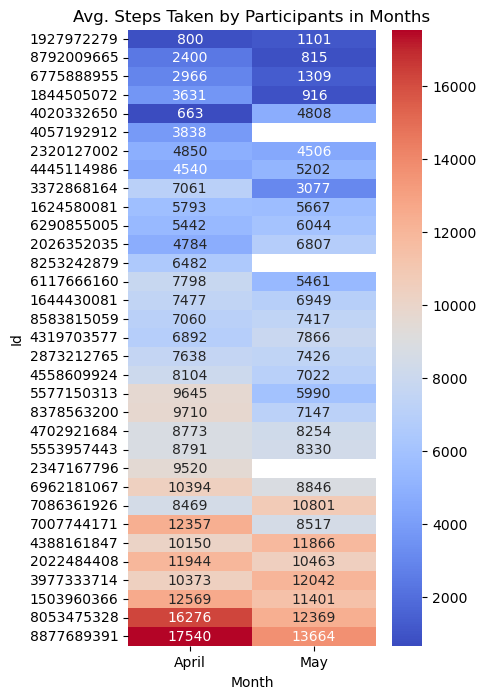

In [28]:
pivot = dailyActivity.pivot_table(values='TotalSteps',index='Id',columns='Month',aggfunc='mean')
pivot["Avg_TotalSteps"] = pivot.mean(axis=1)
pivot = pivot.sort_values("Avg_TotalSteps", ascending=True)
pivot = pivot.drop(columns=["Avg_TotalSteps"])

plt.figure(figsize=(4,8))
sns.heatmap(pivot,cmap="coolwarm",annot=True,fmt=".0f")
plt.title("Avg. Steps Taken by Participants in Months")
plt.show()

#### **2.5 Average Calories burnt per week**

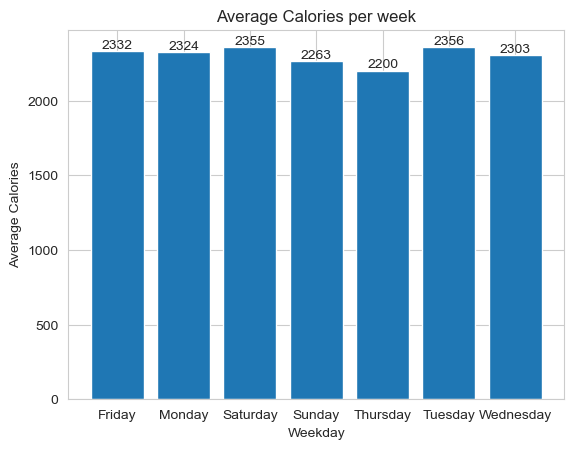

In [102]:
# Calculate the average value of 'calories' for each 'Week'
avg_values = dailyActivity.groupby('Weekday')['Calories'].mean().reset_index()


# Create the bar chart
fig, ax = plt.subplots()
bars = ax.bar(avg_values['Weekday'], avg_values['Calories'])

# Add the average values on top of the bars using ax.bar_label()
ax.bar_label(bars, fmt='%.0f') # fmt='%.2f' formats the label to two decimal places

# Customize the chart
plt.title('Average Calories per week')
plt.xlabel('Weekday')
plt.ylabel('Average Calories')
plt.show()


#### **2.5.1 Average Calories burnt by each participant per week**

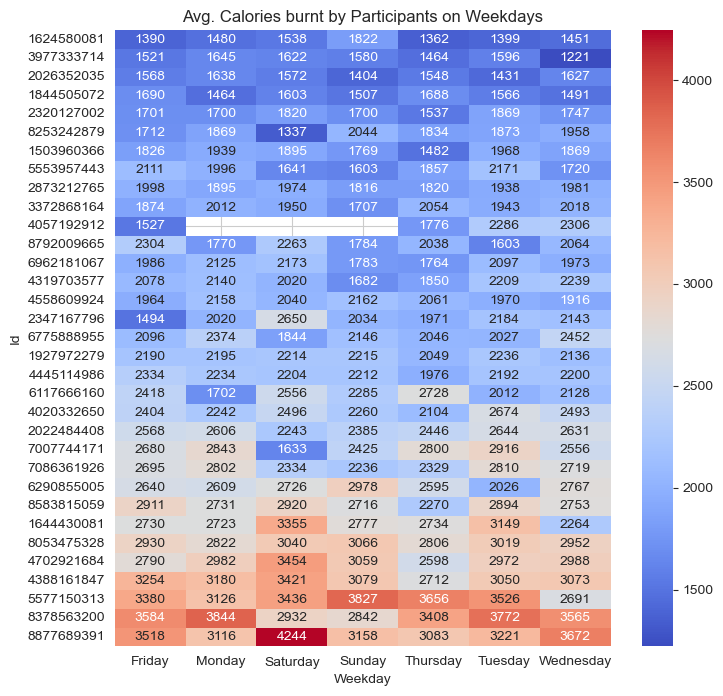

In [31]:
pivot1 = dailyActivity.pivot_table(values='Calories',index='Id',columns='Weekday',aggfunc='mean')
pivot1["Avg_Calories"] = pivot1.mean(axis=1)
pivot1 = pivot1.sort_values("Avg_Calories", ascending=True)
pivot1 = pivot1.drop(columns=["Avg_Calories"])

plt.figure(figsize=(8,8))
sns.heatmap(pivot1,cmap="coolwarm",annot=True,fmt=".0f" )
plt.title("Avg. Calories burnt by Participants on Weekdays")
plt.show()

#### **2.6 Average Calories burnt per month**

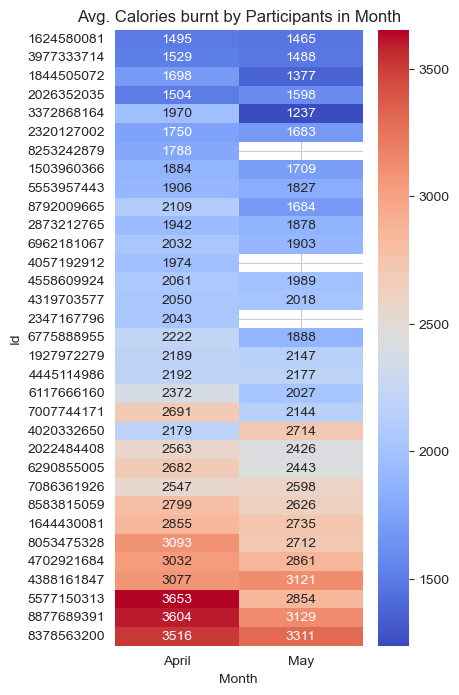

In [32]:
pivot2 = dailyActivity.pivot_table(values='Calories',index='Id',columns='Month',aggfunc='mean')
pivot2["Avg_Calories"] = pivot2.mean(axis=1)
pivot2 = pivot2.sort_values("Avg_Calories", ascending=True)
pivot2 = pivot2.drop(columns=["Avg_Calories"])

plt.figure(figsize=(4,8))
sns.heatmap(pivot2,cmap="coolwarm",annot=True,fmt=".0f" )
plt.title("Avg. Calories burnt by Participants in Month")
plt.show()

* 2200-2400 calories are averagely burnt weekly 




#### **2.7 Average calories burnt Vs. Average Steps per day**


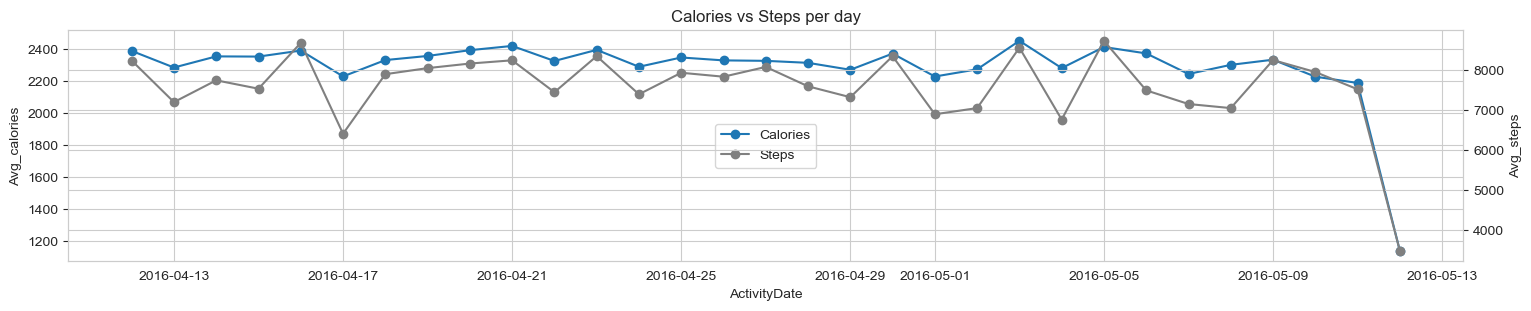

In [33]:

df = dailyActivity.groupby('ActivityDate')[['Calories','TotalSteps']].mean().reset_index()

# Create figure
fig, ax1 = plt.subplots(figsize=(18,3))

# Calories line (left axis)
line1, =ax1.plot(df['ActivityDate'], df['Calories'], marker='o', label='Calories')
ax1.set_xlabel('ActivityDate')
ax1.set_ylabel('Avg_calories')


# Steps line (right axis)
ax2 = ax1.twinx()
line2, = ax2.plot(df['ActivityDate'], df['TotalSteps'],color = 'grey', marker='o', label='Steps')
ax2.set_ylabel('Avg_steps')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center')

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()

# ax1.legend(lines1 + lines2, labels1 + labels2)


plt.title('Calories vs Steps per day')
plt.show()


* Average calories burnt in may is highly fluctuation as there are less respondents




#### **2.8 Total Calories burnt vs. Total Steps**

Text(0.5, 1.0, 'Calories burnt vs. Total Steps')

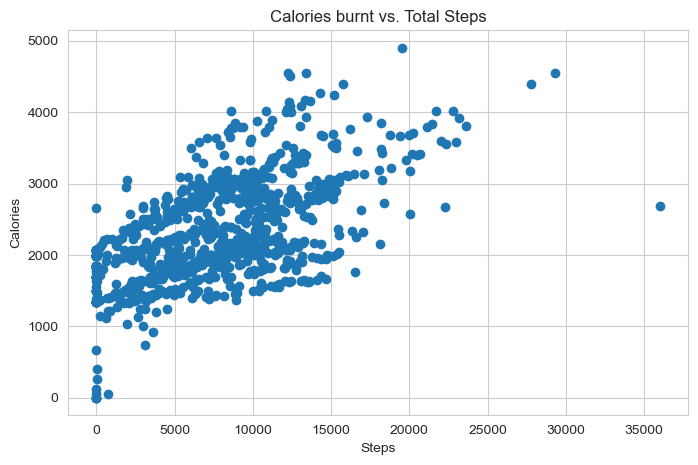

In [34]:
plt.figure(figsize = (8,5))
plt.scatter(x=dailyActivity['TotalSteps'],y = dailyActivity['Calories'])

plt.xlabel("Steps")
plt.ylabel("Calories")
plt.title("Calories burnt vs. Total Steps")

* We can say that total steps is directly proportional to calories burnt. As the no. of steps increases the Calories burnt increases




#### **2.9 Active level by distance**

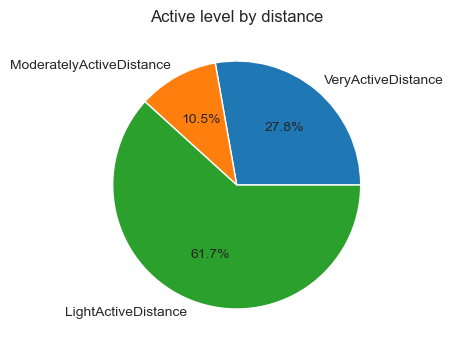

In [35]:
plt.figure(figsize=(4,6))
df = dailyActivity[["VeryActiveDistance","ModeratelyActiveDistance","LightActiveDistance"]].sum()

plt.pie(df.values, labels=df.index, autopct='%1.1f%%')
plt.title("Active level by distance")
plt.show()

* 62% of distance covered by respondents is Light Active Distance, 11% is Moderately Active Distance, 28% is very active distance




#### **2.10 Active level by Minutes**

<Figure size 1800x400 with 0 Axes>

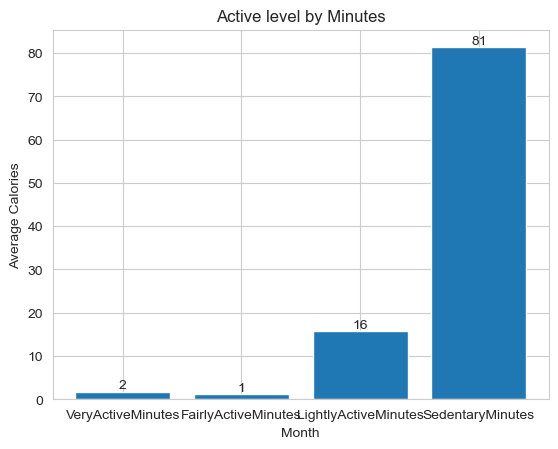

In [36]:
plt.figure(figsize=(18,4))
df1 = dailyActivity[["VeryActiveMinutes","FairlyActiveMinutes","LightlyActiveMinutes","SedentaryMinutes"]].sum()
df = sum(df1.values)

# Create the bar chart
fig, ax = plt.subplots()
bars = ax.bar(df1.index, df1.values/df *100)

# Add the average values on top of the bars using ax.bar_label()
ax.bar_label(bars, fmt='%.0f') # fmt='%.2f' formats the label to two decimal places

# Customize the chart
plt.title('Active level by Minutes')
plt.xlabel('Month')
plt.ylabel('Average Calories')
plt.show()


#### **2.11 Average SedentaryMinutes by Participants on Weekdays**

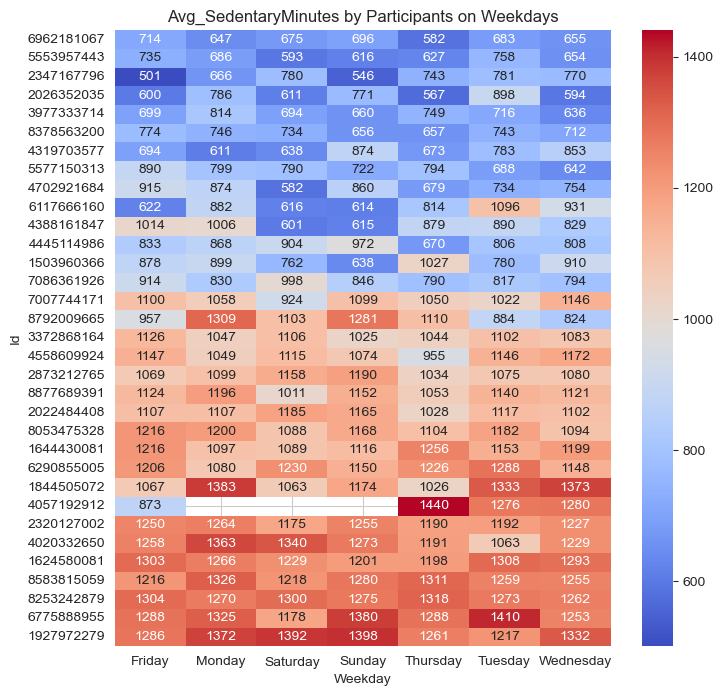

In [37]:
sed = dailyActivity.pivot_table(values='SedentaryMinutes',index='Id',columns='Weekday',aggfunc='mean')
sed["Avg_SedentaryMinutes"] = sed.mean(axis=1)
sed = sed.sort_values("Avg_SedentaryMinutes", ascending=True)
sed = sed.drop(columns=["Avg_SedentaryMinutes"])

plt.figure(figsize=(8,8))
sns.heatmap(sed,cmap="coolwarm",annot=True,fmt=".0f" )
plt.title("Avg_SedentaryMinutes by Participants on Weekdays")
plt.show()

* Lightly Active minutes is the highest

### **Merging daily_Activity and Weight info**

In [38]:
Wlog_info['ActivityDate'] = Wlog_info['Date'].dt.date
dailyActivity['ActivityDate'] = dailyActivity['ActivityDate'].dt.date
Wlog_info1 = Wlog_info[['Id', 'ActivityDate','WeightKg']]
result = pd.merge( dailyActivity,Wlog_info1, on=['Id','ActivityDate'], how='inner')

#### **2.12 Total distance vs. Weight in kgs**

<Axes: xlabel='WeightKg', ylabel='TotalDistance'>

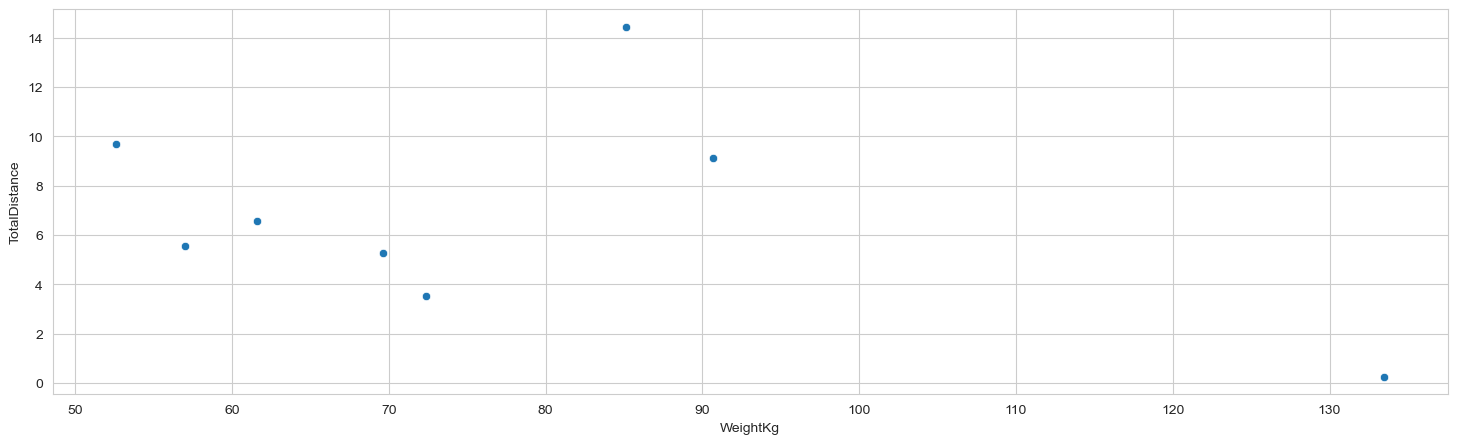

In [39]:
plt.figure(figsize = (18,5))
TDW = result.groupby('Id')[['WeightKg','TotalDistance']].mean()
sns.scatterplot(data=TDW, x='WeightKg', y='TotalDistance')

#### **2.13 BMI Distribution**

In [56]:
Wlog_info['BMI_category'] = np.where(Wlog_info['BMI'] < 18.5, 'Underweight',np.where(Wlog_info['BMI'] < 24.9, 'Normal',np.where(Wlog_info['BMI'] < 29.9, 'Overweight','Obese')))

Text(0.5, 1.0, 'BMI distribution')

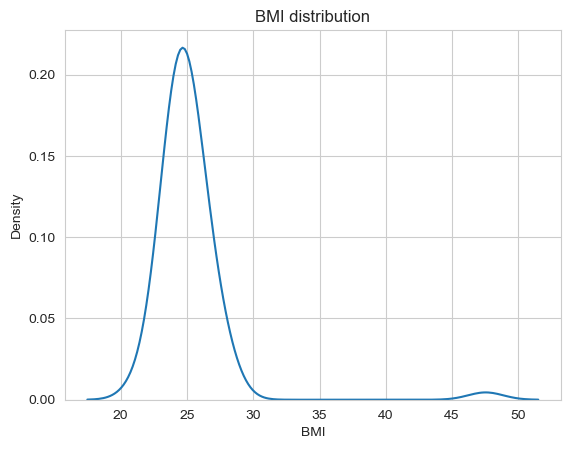

In [68]:
sns.kdeplot(Wlog_info['BMI'])
plt.title("BMI distribution")

* As the weight of person increases the distance covered is reduced




Merging daily_Activity and daily_sleep to see the correlation between distance and sleep of respondents

#### **Merging daily_Activity and daily_sleep**


In [40]:
Sleep_info['ActivityDate'] = Sleep_info['SleepDay'].dt.date
Sleep_info1 = Sleep_info[['Id', 'ActivityDate','TotalMinutesAsleep','TotalTimeInBed']]
result1 = pd.merge( dailyActivity,Sleep_info1, on=['Id','ActivityDate'], how='inner')
DVS = result1.groupby('Id')[['TotalMinutesAsleep','TotalDistance']].mean()
DVS = DVS.reset_index().rename(columns={'index': 'Id'})
DVS['Id'] = DVS['Id'].astype(str)

#### **2.14 Average distance vs. average sleep per user**

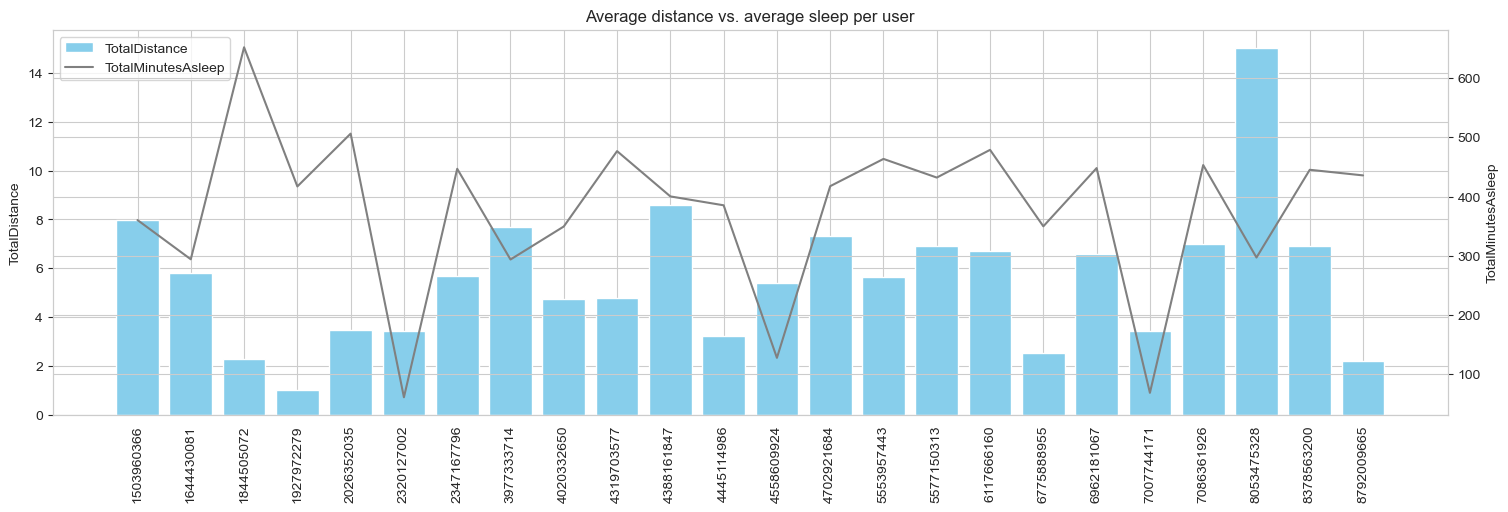

In [97]:
fig,ax1 = plt.subplots(figsize=(18,5))
ax1.bar(DVS['Id'], DVS['TotalDistance'], color="skyblue",label = "TotalDistance" )
ax1.set_ylabel("TotalDistance")
plt.xticks(rotation=90)
ax2 = ax1.twinx()
ax2.plot(DVS['Id'], DVS['TotalMinutesAsleep'], color="grey",label = "TotalMinutesAsleep")
ax2.set_ylabel("TotalMinutesAsleep")
# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Average distance vs. average sleep per user")
plt.show()

* We can't find any relation as there are respondents with good sleep without covering minimum distance and people covering greater distance who are not having good sleep



#### **2.15 Sleep quality by steps**




In [42]:
import pandas as pd
import numpy as np

# 1. Create sleep categories
result1['sleeping_hrs'] = np.where(result1['TotalMinutesAsleep'] <= 300, 'Less than 5h',
                        np.where(result1['TotalMinutesAsleep'] <= 480, 'Less than 8h',
                                 'More than 9h'))

# 2. Create steps categories
result1['steps_taken'] = np.where(result1['TotalSteps'] <= 5000, 'Less than 5000 steps',
                     np.where(result1['TotalSteps'] <= 10000, '5001 to 10000 steps',
                     np.where(result1['TotalSteps'] <= 15000, '10001 to 15000 steps',
                              'More than 15000 steps')))

# 3. Group by sleep and steps and count
summary = (result1.groupby(['sleeping_hrs', 'steps_taken'], as_index=False)
             .size()   # .size() counts rows per group
             .rename(columns={'size':'counts'}))

# 4. Convert steps_taken to categorical with order
steps_order = ['Less than 5000 steps', '5001 to 10000 steps',
               '10001 to 15000 steps', 'More than 15000 steps']

summary['active_level'] = pd.Categorical(summary['steps_taken'], categories=steps_order, ordered=True)

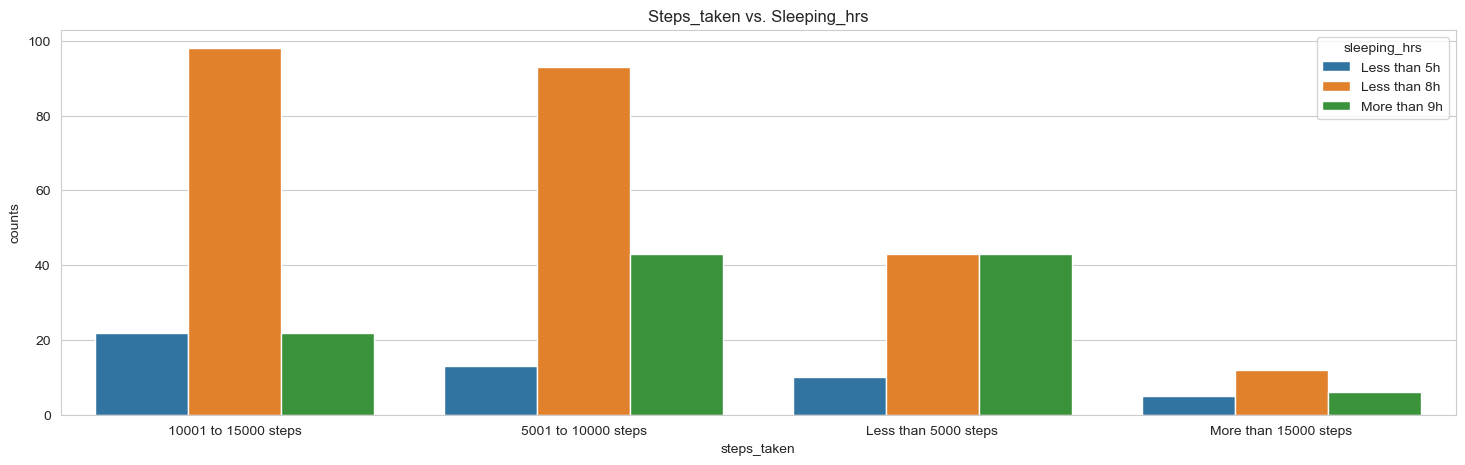

In [43]:
sns.set_style("whitegrid")
plt.figure(figsize = (18,5))
sns.barplot(data=summary, x='steps_taken', y='counts', hue='sleeping_hrs')
plt.title('Steps_taken vs. Sleeping_hrs')
plt.show()

* Moderately Walking between 5000 to 15000 steps can help to have good sleep between 5 hrs to 9hrs

* people walking more than 15000 steps are not having enough sleep




#### **2.16 struggling to sleep vs. Steps taken**



In [44]:
result1['struggling_tosleep'] = result1['TotalTimeInBed'] - result1['TotalMinutesAsleep']

<Axes: xlabel='TotalSteps', ylabel='struggling_tosleep'>

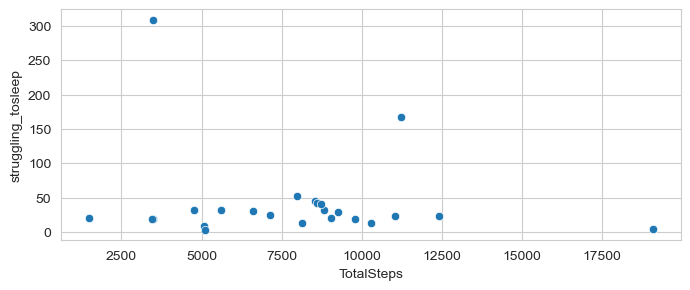

In [45]:
plt.figure(figsize = (8,3))
TSS = result1.groupby('Id')[['TotalSteps','struggling_tosleep']].mean()
sns.scatterplot(data=TSS, x='TotalSteps', y='struggling_tosleep')

* Majority of people are sleeping within 1 hour in bed and the extreme cases seem to be outliers



#### **2.17 Average sleep per user**


<Axes: xlabel='TotalMinutesAsleep', ylabel='Count'>

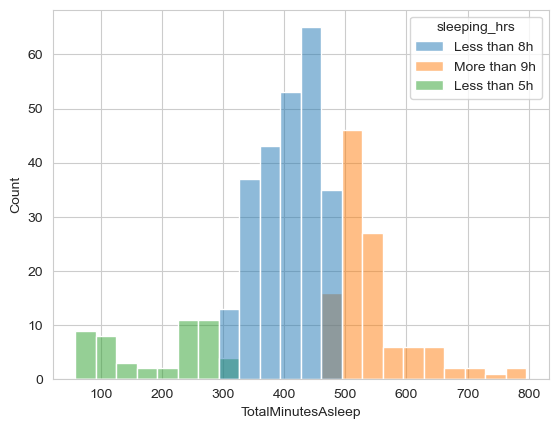

In [46]:
sns.histplot(data=result1,x='TotalMinutesAsleep',hue='sleeping_hrs')

* Most people have sleep between 300-520 minutes (i.e.,5hrs - 8.5 hrs)



#### **2.18 Average heart_rate per user**


As the heart_rate is in seconds, we are taking average heart_rate per day per respondent

In [47]:
Hrate_sec['ActivityDate'] = Hrate_sec['Time'].dt.date

In [48]:
Hrate_grid = Hrate_sec.groupby(['Id'], as_index=False).agg({'Value': 'mean',})

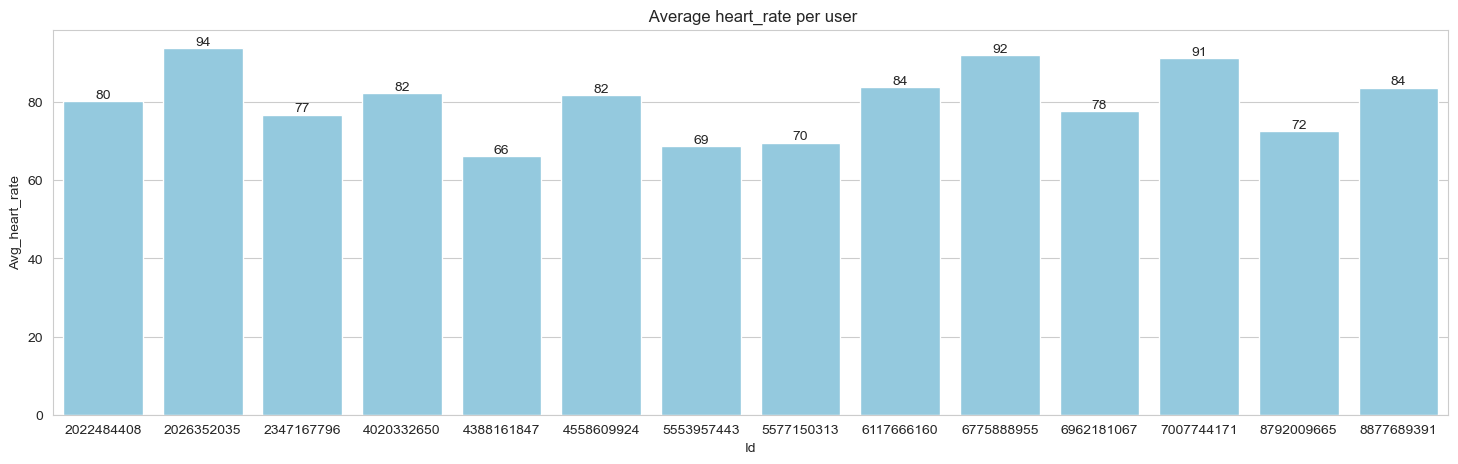

In [49]:
plt.figure(figsize=(18,5))
ax = sns.barplot(data=Hrate_grid, x="Id", y="Value", color="skyblue",errorbar=None)
ax.bar_label(ax.containers[0],fmt='%.0f')
ax.set_title(' Average heart_rate per user')
ax.set_xlabel('Id')
ax.set_ylabel('Avg_heart_rate')
plt.show()

#### **2.19 Average heart_rate per month**

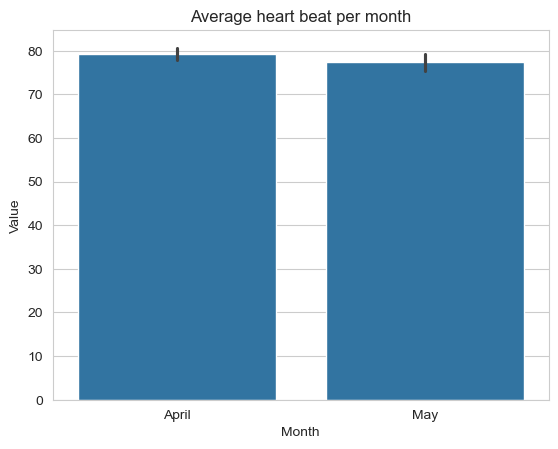

In [104]:
Hrate_dail = Hrate_sec.groupby(['Id','ActivityDate'], as_index=False).agg({'Value': 'mean',})
Hrate_dail['ActivityDate'] =pd.to_datetime( Hrate_dail['ActivityDate'])
Hrate_dail['Month'] = Hrate_dail['ActivityDate'].dt.month_name()
Hrate_dail['Week'] = Hrate_dail['ActivityDate'].dt.day_name()
sns.barplot(data =Hrate_dail, x = 'Month',y = 'Value')
plt.title('Average heart beat per month')
plt.show()

* A normal resting heart rate for adults ranges from 60 to 100 beats per minute.



#### **2.20 Average heart_rate per week**

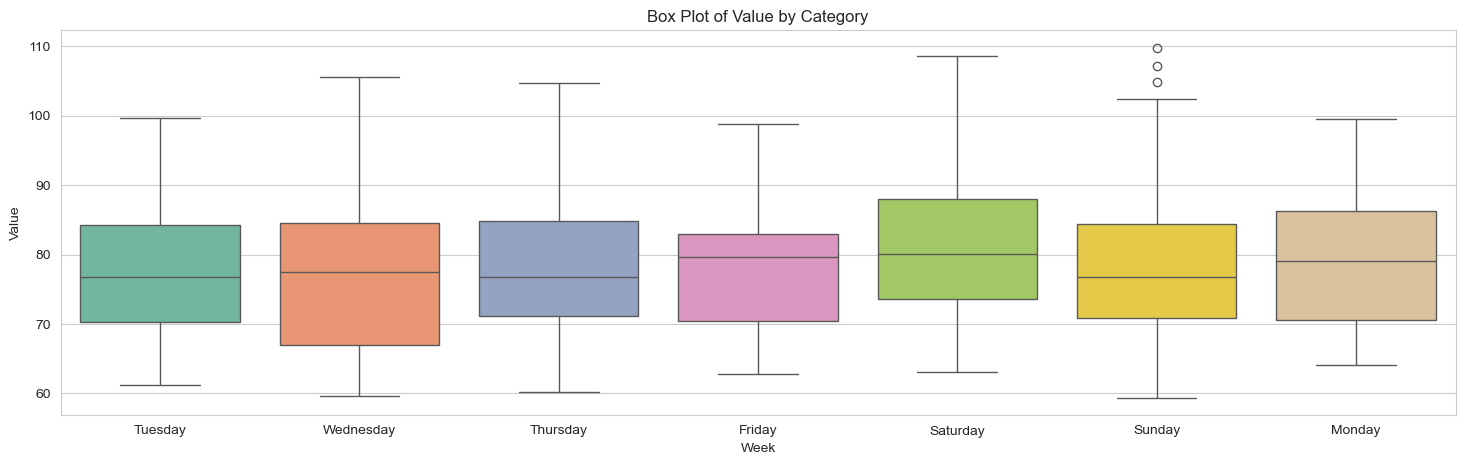

In [54]:
plt.figure(figsize = (18,5))
sns.set_style('whitegrid')

sns.boxplot(data=Hrate_dail, x='Week', y='Value', palette='Set2')

plt.title('Box Plot of Value by Category')
plt.show()

We can see customers with avg_heart_rate of 66 and 94 which is normal.



### **Business Insights**

Respondents are mostly using the device for tracking steps, heart-beat, sleep , weight info ,calories burnt

1. Respondents are mostly using the device for tracking steps, heart-beat, sleep , weight info ,calories burnt
2. Many users do not reach recommended 10,000 steps/day only 6 participants out of 33
3. Suggest customer to have regular activity of walking by giving personalized messages as they have forgot to walk on a particular day.
4. Customized messages of calories intake, calories burnt, weight info, sleep , heart-rate, steps taken on particular day.
5. Higher activity correlates with higher calorie burn 
6. The participants who walk 10,000 steps but the calories burnt are less because of the calorie intake suggest them on diet and calories to maintain healthy life style
7. Inform customers with unusual heart beat for check-up
8. Some users fall into overweight BMI category , give suggestion on food habits and activity best suited to reduce calories.
9. Some users do not meet sleep recommendations ,send customized messages of how get sleep better to participants who have sleep <5hrs and struggling to sleep 
10. Users spend large time sedentary 